---
<img src=https://audiovisuales.icesi.edu.co/assets/custom/images/ICESI_logo_prin_descriptor_RGB_POSITIVO_0924.jpg width=300>

# **<big><big>Algoritmos y Programación III</big></big>**
**Proyecto final — Clasificación de calidad de frutas**

---

- **Martinez Vasquez Luna Catalina - A00401964**<br>
- **Mosquera Daza Renzo Fernando - A00401681**<br>
- **Tobar Gómez Valentina - A00401749**<br>

---

# Notebook 03 — Modelos de Machine Learning tradicionales


## 1. Propósito

En este notebook usamos los archivos que ya dejamos preparados en el Notebook 02 para entrenar modelos clásicos de Machine Learning. No volvemos a limpiar imágenes ni a partir datos; aquí solamente cargamos las particiones finales, convertimos cada imagen procesada en un vector y comparamos modelos para dos tareas:

- **Calidad:** `bad`, `regular`, `good`.
- **Tamaño relativo:** `small`, `medium`, `large`.

Probamos **Random Forest** y **SVM lineal** porque son modelos vistos en el curso y sirven como una base clara antes de pasar a una CNN. Random Forest suele manejar bien relaciones no lineales y SVM lineal permite revisar si una frontera relativamente simple ya separa las clases de forma aceptable.


## 2. Importación de librerías

Cargamos las librerías para leer los metadatos procesados, convertir las imágenes en vectores, entrenar modelos, calcular métricas y guardar los modelos que después usará la aplicación.


In [1]:
from pathlib import Path
import json
import warnings
import time

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from IPython.display import display

import joblib
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")
pd.set_option("display.max_columns", 90)
pd.set_option("display.max_rows", 90)
pd.set_option("display.max_colwidth", 180)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
RANDOM_STATE = 42

## 3. Rutas y parámetros

Nosotros usamos directamente los archivos creados por el Notebook 02. El tamaño de entrada para los modelos tradicionales queda en `48 x 48`, porque así reducimos el costo computacional sin perder la estructura general de cada fruta.


In [2]:
PROJECT_ROOT = Path.cwd().parent
ANNOTATIONS_DIR = PROJECT_ROOT / "data" / "annotations"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

TRAIN_PATH = ANNOTATIONS_DIR / "train_metadata.csv"
BALANCED_TRAIN_PATH = ANNOTATIONS_DIR / "train_metadata_balanced.csv"
VAL_PATH = ANNOTATIONS_DIR / "val_metadata.csv"
TEST_PATH = ANNOTATIONS_DIR / "test_metadata.csv"
SUMMARY_PATH = TABLES_DIR / "03_model_comparison.csv"

MODEL_IMAGE_SIZE = 48
CV_FOLDS = 3
GRID_N_JOBS = 1
SCORING = "f1_macro"
QUALITY_LABELS = ["bad", "regular", "good"]
SIZE_LABELS = ["small", "medium", "large"]

for directory in [MODELS_DIR, FIGURES_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Proyecto:", PROJECT_ROOT)
print("Train:", TRAIN_PATH)
print("Train balanceado disponible:", BALANCED_TRAIN_PATH.exists())
print("Validation:", VAL_PATH)
print("Test:", TEST_PATH)
print("Tamaño de entrada:", f"{MODEL_IMAGE_SIZE}x{MODEL_IMAGE_SIZE}")

Proyecto: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3
Train: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\train_metadata.csv
Train balanceado disponible: True
Validation: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\val_metadata.csv
Test: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\test_metadata.csv
Tamaño de entrada: 48x48


## 4. Carga de metadatos procesados

Cargamos las particiones de entrenamiento, validación y prueba que ya fueron generadas en el Notebook 02. Para evitar errores, verificamos que existan las columnas mínimas que este notebook necesita: `processed_relative_path`, `quality_label` y `size_label`.


In [3]:
def read_metadata(path, split_name):
    if not path.exists():
        raise FileNotFoundError(f"No existe {path}. Ejecuta primero el Notebook 02.")
    data = pd.read_csv(path)
    data["split"] = split_name
    return data

train_df = read_metadata(TRAIN_PATH, "train")
val_df = read_metadata(VAL_PATH, "val")
test_df = read_metadata(TEST_PATH, "test")

required_columns = {"processed_relative_path", "quality_label", "size_label"}
missing_columns = required_columns - set(train_df.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas en los metadatos procesados: {sorted(missing_columns)}")

metadata_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

display(metadata_df.groupby(["split", "quality_label"]).size().unstack(fill_value=0).reindex(index=["train", "val", "test"], columns=QUALITY_LABELS, fill_value=0))
display(metadata_df.groupby(["split", "size_label"]).size().unstack(fill_value=0).reindex(index=["train", "val", "test"], columns=SIZE_LABELS, fill_value=0))

quality_label,bad,regular,good
split,,,
train,618,2110,1016
val,206,703,339
test,206,705,338


size_label,small,medium,large
split,,,
train,1250,1249,1245
val,416,416,416
test,416,417,416


## 5. Vectorización compatible con la aplicación

Abrimos cada imagen procesada, la dejamos en RGB, la ajustamos a `48 x 48`, la normalizamos entre 0 y 1 y la convertimos en un vector. Ese mismo contrato queda guardado después en los archivos de configuración para que la aplicación use exactamente el mismo preprocesamiento.


In [4]:
def image_path_from_relative(relative_path):
    path = Path(str(relative_path).replace(chr(92), "/").strip())
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path


def image_to_vector(relative_path):
    image_path = image_path_from_relative(relative_path)
    with Image.open(image_path) as image:
        image = ImageOps.exif_transpose(image).convert("RGB")
        image = ImageOps.pad(image, (MODEL_IMAGE_SIZE, MODEL_IMAGE_SIZE), color=(255, 255, 255), centering=(0.5, 0.5))
    array = np.asarray(image).astype("float32") / 255.0
    return array.reshape(-1)


def build_matrix(data, name):
    vectors = []
    total = len(data)
    for index, relative_path in enumerate(data["processed_relative_path"], start=1):
        vectors.append(image_to_vector(relative_path))
        if index % 500 == 0 or index == total:
            print(f"{name}: {index}/{total}", end="\r")
    print()
    return np.vstack(vectors).astype("float32")

X_train = build_matrix(train_df, "train")
X_val = build_matrix(val_df, "val")
X_test = build_matrix(test_df, "test")

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


train: 3744/3744
val: 1248/1248
test: 1249/1249
X_train: (3744, 6912)
X_val: (1248, 6912)
X_test: (1249, 6912)


## 6. Variables objetivo

Preparamos dos variables objetivo separadas. La primera corresponde a la calidad de la fruta y la segunda al tamaño relativo estimado en el Notebook 02.


In [5]:
y_train_quality = train_df["quality_label"].astype(str).values
y_val_quality = val_df["quality_label"].astype(str).values
y_test_quality = test_df["quality_label"].astype(str).values

y_train_size = train_df["size_label"].astype(str).values
y_val_size = val_df["size_label"].astype(str).values
y_test_size = test_df["size_label"].astype(str).values

targets = {
    "quality": {
        "train": y_train_quality,
        "val": y_val_quality,
        "test": y_test_quality,
        "labels": QUALITY_LABELS,
        "label_name": "quality_label"
    },
    "size": {
        "train": y_train_size,
        "val": y_val_size,
        "test": y_test_size,
        "labels": SIZE_LABELS,
        "label_name": "size_label"
    }
}

for target_name, target_data in targets.items():
    print(target_name)
    display(pd.Series(target_data["train"]).value_counts().reindex(target_data["labels"], fill_value=0).to_frame("train"))

quality


,train
bad,618
regular,2110
good,1016


size


,train
small,1250
medium,1249
large,1245


## 7. Funciones de entrenamiento y evaluación

Usamos `accuracy` como una lectura general, pero la métrica principal para comparar modelos es `f1_macro`, porque el dataset no está perfectamente balanceado en calidad. Así evitamos que una clase mayoritaria o más fácil domine toda la evaluación.


In [6]:
def available_cv(y):
    counts = pd.Series(y).value_counts()
    minimum = int(counts.min())
    if minimum < 2:
        raise ValueError("No hay suficientes ejemplos por clase para validación cruzada estratificada.")
    return StratifiedKFold(n_splits=min(CV_FOLDS, minimum), shuffle=True, random_state=RANDOM_STATE)


def build_random_forest_grid(y):
    pipeline = Pipeline([
        ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced_subsample", n_jobs=-1))
    ])
    params = {
        "classifier__n_estimators": [150, 250],
        "classifier__max_depth": [None, 20],
        "classifier__min_samples_leaf": [1, 2],
        "classifier__max_features": ["sqrt"]
    }
    return GridSearchCV(pipeline, params, scoring=SCORING, cv=available_cv(y), n_jobs=GRID_N_JOBS, refit=True, verbose=0)


def build_svm_grid(y):
    pipeline = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("classifier", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=6000))
    ])
    params = {
        "classifier__C": [0.05, 0.2, 1.0]
    }
    return GridSearchCV(pipeline, params, scoring=SCORING, cv=available_cv(y), n_jobs=GRID_N_JOBS, refit=True, verbose=0)


def evaluate_model(model, X, y, model_name, target_name, dataset_name, labels):
    prediction = model.predict(X)
    return {
        "target": target_name,
        "dataset": dataset_name,
        "model": model_name,
        "accuracy": accuracy_score(y, prediction),
        "precision_macro": precision_score(y, prediction, average="macro", zero_division=0),
        "recall_macro": recall_score(y, prediction, average="macro", zero_division=0),
        "f1_macro": f1_score(y, prediction, average="macro", zero_division=0),
        "f1_weighted": f1_score(y, prediction, average="weighted", zero_division=0),
        "kappa": cohen_kappa_score(y, prediction),
        "labels": ", ".join(labels)
    }


def show_confusion_matrix(model, X, y, labels, model_name, target_name, dataset_name):
    prediction = model.predict(X)
    ConfusionMatrixDisplay.from_predictions(y, prediction, labels=labels, normalize=None, colorbar=False)
    plt.title(f"{target_name} | {model_name} | {dataset_name}")
    plt.tight_layout()
    figure_path = FIGURES_DIR / f"03_confusion_{target_name}_{model_name.lower().replace(' ', '_')}_{dataset_name}.png"
    plt.savefig(figure_path, dpi=160)
    plt.show()
    print(classification_report(y, prediction, labels=labels, zero_division=0))

## 8. Línea base

Primero entrenamos una línea base que siempre predice la clase más frecuente. Esto nos permite comprobar si Random Forest y SVM realmente están aprendiendo patrones visuales o si solamente están copiando el desbalance del conjunto.


In [7]:
baseline_rows = []
baseline_models = {}

for target_name, target_data in targets.items():
    dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
    dummy.fit(X_train, target_data["train"])
    baseline_models[target_name] = dummy
    baseline_rows.append(evaluate_model(dummy, X_val, target_data["val"], "Baseline mayoría", target_name, "val", target_data["labels"]))
    baseline_rows.append(evaluate_model(dummy, X_test, target_data["test"], "Baseline mayoría", target_name, "test", target_data["labels"]))

baseline_results = pd.DataFrame(baseline_rows)
display(baseline_results)

,target,dataset,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,kappa,labels
0,quality,val,Baseline mayoría,0.563301,0.187767,0.333333,0.240219,0.405946,0.0,"bad, regular, good"
1,quality,test,Baseline mayoría,0.564452,0.188151,0.333333,0.240532,0.407306,0.0,"bad, regular, good"
2,size,val,Baseline mayoría,0.333333,0.111111,0.333333,0.166667,0.166667,0.0,"small, medium, large"
3,size,test,Baseline mayoría,0.333066,0.111022,0.333333,0.166567,0.166433,0.0,"small, medium, large"


## 9. Entrenamiento de Random Forest y SVM

Ajustamos hiperparámetros con validación cruzada sobre el conjunto de entrenamiento. Después evaluamos cada modelo en entrenamiento, validación y prueba para revisar desempeño y posible sobreajuste.


In [8]:
trained_models = {}
model_rows = []

for target_name, target_data in targets.items():
    print("Entrenando Random Forest para", target_name)
    start_time = time.time()
    rf_grid = build_random_forest_grid(target_data["train"])
    rf_grid.fit(X_train, target_data["train"])
    trained_models[(target_name, "Random Forest")] = rf_grid.best_estimator_
    print("Mejores parámetros RF:", rf_grid.best_params_)
    print("Mejor CV RF:", round(float(rf_grid.best_score_), 4))
    print("Tiempo RF:", round((time.time() - start_time) / 60, 2), "minutos")

    print("Entrenando SVM para", target_name)
    start_time = time.time()
    svm_grid = build_svm_grid(target_data["train"])
    svm_grid.fit(X_train, target_data["train"])
    trained_models[(target_name, "SVM lineal")] = svm_grid.best_estimator_
    print("Mejores parámetros SVM:", svm_grid.best_params_)
    print("Mejor CV SVM:", round(float(svm_grid.best_score_), 4))
    print("Tiempo SVM:", round((time.time() - start_time) / 60, 2), "minutos")

    for model_name in ["Random Forest", "SVM lineal"]:
        model = trained_models[(target_name, model_name)]
        model_rows.append(evaluate_model(model, X_train, target_data["train"], model_name, target_name, "train", target_data["labels"]))
        model_rows.append(evaluate_model(model, X_val, target_data["val"], model_name, target_name, "val", target_data["labels"]))
        model_rows.append(evaluate_model(model, X_test, target_data["test"], model_name, target_name, "test", target_data["labels"]))

model_results = pd.concat([baseline_results, pd.DataFrame(model_rows)], ignore_index=True)
model_results["accuracy"] = model_results["accuracy"].round(4)
model_results["precision_macro"] = model_results["precision_macro"].round(4)
model_results["recall_macro"] = model_results["recall_macro"].round(4)
model_results["f1_macro"] = model_results["f1_macro"].round(4)
model_results["f1_weighted"] = model_results["f1_weighted"].round(4)
model_results["kappa"] = model_results["kappa"].round(4)
model_results.to_csv(SUMMARY_PATH, index=False, encoding="utf-8")

display(model_results.sort_values(["target", "dataset", "f1_macro"], ascending=[True, True, False]))
print("Comparación guardada en:", SUMMARY_PATH)

Entrenando Random Forest para quality
Mejores parámetros RF: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 250}
Mejor CV RF: 0.9455
Tiempo RF: 1.37 minutos
Entrenando SVM para quality
Mejores parámetros SVM: {'classifier__C': 0.05}
Mejor CV SVM: 0.8598
Tiempo SVM: 22.33 minutos
Entrenando Random Forest para size
Mejores parámetros RF: {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 150}
Mejor CV RF: 0.76
Tiempo RF: 1.73 minutos
Entrenando SVM para size
Mejores parámetros SVM: {'classifier__C': 0.05}
Mejor CV SVM: 0.6524
Tiempo SVM: 52.69 minutos


,target,dataset,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,kappa,labels
6,quality,test,Random Forest,0.9584,0.9507,0.9425,0.9465,0.9582,0.9279,"bad, regular, good"
9,quality,test,SVM lineal,0.8927,0.8600,0.8575,0.8583,0.8917,0.8153,"bad, regular, good"
1,quality,test,Baseline mayoría,0.5645,0.1882,0.3333,0.2405,0.4073,0.0000,"bad, regular, good"
7,quality,train,SVM lineal,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,"bad, regular, good"
4,quality,train,Random Forest,0.9987,0.9985,0.9987,0.9986,0.9987,0.9977,"bad, regular, good"
5,quality,val,Random Forest,0.9567,0.9447,0.9457,0.9451,0.9568,0.9256,"bad, regular, good"
8,quality,val,SVM lineal,0.8990,0.8651,0.8796,0.8719,0.8998,0.8284,"bad, regular, good"
0,quality,val,Baseline mayoría,0.5633,0.1878,0.3333,0.2402,0.4059,0.0000,"bad, regular, good"
12,size,test,Random Forest,0.7582,0.7683,0.7583,0.7582,0.7582,0.6373,"small, medium, large"
15,size,test,SVM lineal,0.6709,0.6692,0.6710,0.6696,0.6695,0.5064,"small, medium, large"


Comparación guardada en: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\results\tables\03_model_comparison.csv


## 10. Matrices de confusión

Revisamos las matrices de confusión sobre el conjunto de prueba. Esta parte sirve para identificar qué clases se confunden más y para preparar la discusión del informe final.


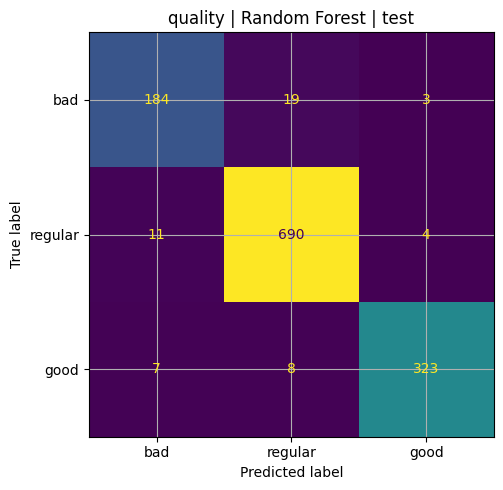

              precision    recall  f1-score   support

         bad       0.91      0.89      0.90       206
     regular       0.96      0.98      0.97       705
        good       0.98      0.96      0.97       338

    accuracy                           0.96      1249
   macro avg       0.95      0.94      0.95      1249
weighted avg       0.96      0.96      0.96      1249



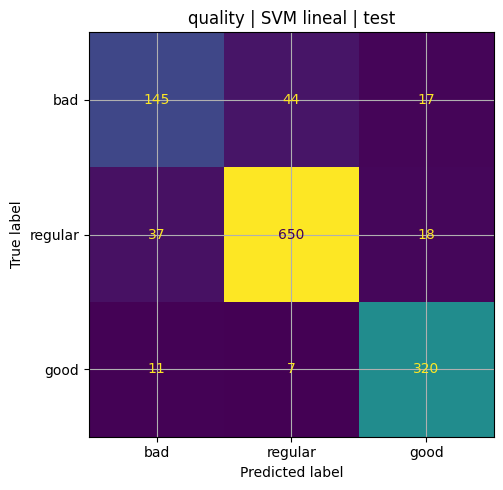

              precision    recall  f1-score   support

         bad       0.75      0.70      0.73       206
     regular       0.93      0.92      0.92       705
        good       0.90      0.95      0.92       338

    accuracy                           0.89      1249
   macro avg       0.86      0.86      0.86      1249
weighted avg       0.89      0.89      0.89      1249



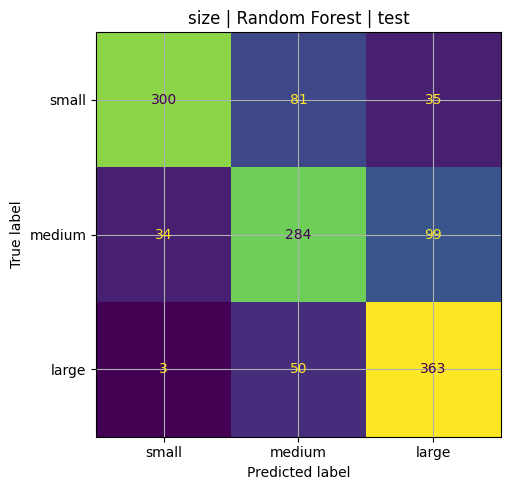

              precision    recall  f1-score   support

       small       0.89      0.72      0.80       416
      medium       0.68      0.68      0.68       417
       large       0.73      0.87      0.80       416

    accuracy                           0.76      1249
   macro avg       0.77      0.76      0.76      1249
weighted avg       0.77      0.76      0.76      1249



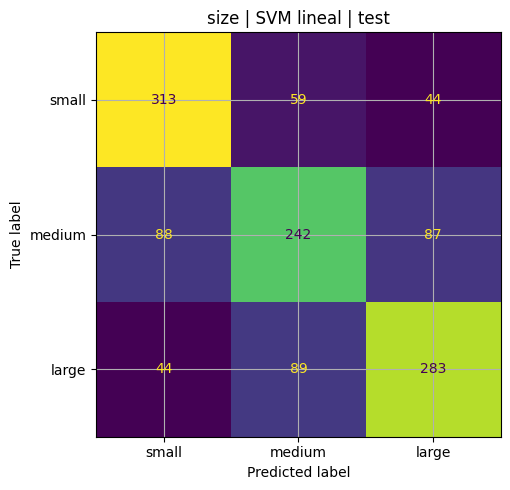

              precision    recall  f1-score   support

       small       0.70      0.75      0.73       416
      medium       0.62      0.58      0.60       417
       large       0.68      0.68      0.68       416

    accuracy                           0.67      1249
   macro avg       0.67      0.67      0.67      1249
weighted avg       0.67      0.67      0.67      1249



In [9]:
for target_name, target_data in targets.items():
    test_results = model_results[(model_results["target"] == target_name) & (model_results["dataset"] == "test") & (model_results["model"].isin(["Random Forest", "SVM lineal"]))]
    ordered_models = test_results.sort_values("f1_macro", ascending=False)["model"].tolist()
    for model_name in ordered_models:
        show_confusion_matrix(trained_models[(target_name, model_name)], X_test, target_data["test"], target_data["labels"], model_name, target_name, "test")

## 11. Comparación visual de resultados

Graficamos el `f1_macro` en entrenamiento, validación y prueba. Si entrenamiento queda muy alto y prueba baja, lo tomamos como señal de posible sobreajuste.


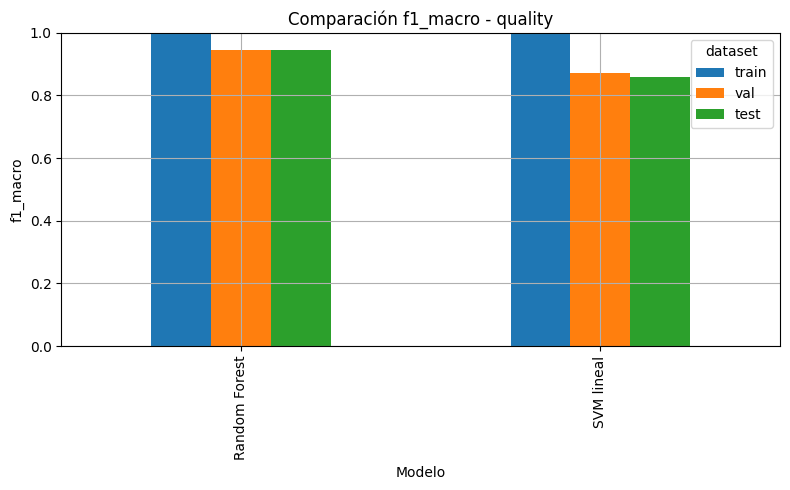

dataset,train,val,test
model,,,
Random Forest,0.9986,0.9451,0.9465
SVM lineal,1.0000,0.8719,0.8583


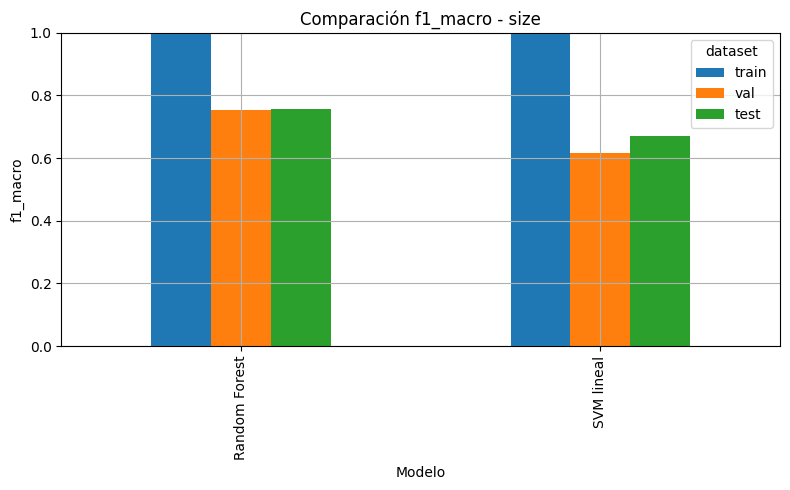

dataset,train,val,test
model,,,
Random Forest,1.0000,0.7530,0.7582
SVM lineal,0.9963,0.6172,0.6696


In [10]:
plot_df = model_results[model_results["model"].isin(["Random Forest", "SVM lineal"])]
for target_name in ["quality", "size"]:
    local = plot_df[(plot_df["target"] == target_name) & (plot_df["dataset"].isin(["train", "val", "test"]))]
    pivot = local.pivot(index="model", columns="dataset", values="f1_macro").reindex(columns=["train", "val", "test"])
    ax = pivot.plot(kind="bar")
    ax.set_title(f"Comparación f1_macro - {target_name}")
    ax.set_xlabel("Modelo")
    ax.set_ylabel("f1_macro")
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"03_f1_macro_{target_name}.png", dpi=160)
    plt.show()
    display(pivot)

## 12. Guardado de modelos para la aplicación

Guardamos los modelos entrenados en la carpeta `models/` junto con un archivo `.json` de configuración. La aplicación podrá leer ese `.json` para saber el tamaño de imagen, las clases y el tipo de preprocesamiento esperado por cada modelo.


In [11]:
def save_model(model, filename, target_name, labels, family):
    model_path = MODELS_DIR / filename
    config_path = MODELS_DIR / f"{model_path.stem}_config.json"
    joblib.dump(model, model_path)
    config = {
        "task": target_name,
        "target": target_name,
        "classes": labels,
        "labels": labels,
        "quality_labels": labels if target_name == "quality" else QUALITY_LABELS,
        "size_labels": labels if target_name == "size" else SIZE_LABELS,
        "img_size": [MODEL_IMAGE_SIZE, MODEL_IMAGE_SIZE],
        "image_size": [MODEL_IMAGE_SIZE, MODEL_IMAGE_SIZE],
        "color_mode": "RGB",
        "scale": 255.0,
        "flatten": True,
        "model_family": family,
        "preprocessing": "ImageOps.pad, RGB, resize, numpy flatten, scale 255"
    }
    config_path.write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
    return model_path, config_path

saved_records = []
for target_name, target_data in targets.items():
    for model_name, family, filename in [
        ("Random Forest", "random_forest", f"random_forest_{target_name}.pkl"),
        ("SVM lineal", "support_vector_machine", f"svm_{target_name}.pkl")
    ]:
        model_path, config_path = save_model(trained_models[(target_name, model_name)], filename, target_name, target_data["labels"], family)
        saved_records.append({
            "target": target_name,
            "model": model_name,
            "model_path": model_path.relative_to(PROJECT_ROOT).as_posix(),
            "config_path": config_path.relative_to(PROJECT_ROOT).as_posix()
        })

saved_models_df = pd.DataFrame(saved_records)
saved_models_df.to_csv(TABLES_DIR / "03_saved_models.csv", index=False, encoding="utf-8")
display(saved_models_df)

,target,model,model_path,config_path
0,quality,Random Forest,models/random_forest_quality.pkl,models/random_forest_quality_config.json
1,quality,SVM lineal,models/svm_quality.pkl,models/svm_quality_config.json
2,size,Random Forest,models/random_forest_size.pkl,models/random_forest_size_config.json
3,size,SVM lineal,models/svm_size.pkl,models/svm_size_config.json


## 13. Modelo recomendado

Escogemos el modelo con mayor `f1_macro` en prueba para cada tarea. También calculamos la diferencia entre entrenamiento y prueba para dejar explícito si el modelo generaliza bien o si parece estar sobreajustado.


In [12]:
recommended_rows = []
for target_name in ["quality", "size"]:
    candidates = model_results[(model_results["target"] == target_name) & (model_results["dataset"] == "test") & (model_results["model"].isin(["Random Forest", "SVM lineal"]))].copy()
    best = candidates.sort_values(["f1_macro", "accuracy"], ascending=False).iloc[0]
    train_metric = model_results[(model_results["target"] == target_name) & (model_results["dataset"] == "train") & (model_results["model"] == best["model"])]["f1_macro"].iloc[0]
    recommended_rows.append({
        "target": target_name,
        "recommended_model": best["model"],
        "test_accuracy": best["accuracy"],
        "test_f1_macro": best["f1_macro"],
        "train_test_gap_f1_macro": round(float(train_metric - best["f1_macro"]), 4)
    })

recommended_df = pd.DataFrame(recommended_rows)
recommended_df.to_csv(TABLES_DIR / "03_recommended_models.csv", index=False, encoding="utf-8")
display(recommended_df)

,target,recommended_model,test_accuracy,test_f1_macro,train_test_gap_f1_macro
0,quality,Random Forest,0.9584,0.9465,0.0521
1,size,Random Forest,0.7582,0.7582,0.2418


## 14. Lectura final de resultados

Con la corrida actual, Random Forest queda como el modelo recomendado para las dos tareas. En calidad, el resultado es fuerte porque el `f1_macro` de prueba queda alrededor de 0.95 y la diferencia frente al entrenamiento es baja. En tamaño, el resultado mejora claramente la línea base, pero la diferencia entre entrenamiento y prueba es mayor; por eso lo tomamos como útil para la aplicación, aunque debe explicarse como una estimación relativa y no como una medición perfecta del tamaño físico.

La tarea de tamaño sigue siendo la más difícil porque depende de la distancia a la cámara, la presencia de manos, el recorte, el fondo y la escala aparente de la fruta. Para el informe, conviene decir que el Notebook 02 reduce ese problema mediante segmentación y estimación relativa por producto, mientras que el Notebook 03 evalúa qué tanto esos datos ya permiten aprender patrones consistentes.
